# Análise Exploratória de Dados — Customer Support Ticket Dataset

**Projeto de Bloco: Análise e Segurança de Agentes de IA**

---

## 1. Compreensão do problema e do dataset

### 1.1 Contexto do projeto

O objetivo do bloco é construir um **sistema de atendimento ao cliente alimentado por IA**: um
agente que recebe a mensagem de um cliente e identifica a **intenção** por trás dela (problema
técnico, cobrança, reembolso, dúvida de produto, cancelamento), para então encaminhar ou responder
adequadamente. A etapa atual (**TP1**) antecede qualquer modelagem: escolher o dataset, entendê-lo
com rigor estatístico e preparar a base que sustentará o modelo e a API.

**Perguntas que este EDA deve responder:**

1. O que o dataset representa e de onde veio?
2. Qual a qualidade dos dados? O que precisa de limpeza antes da modelagem?
3. Como se distribuem as variáveis-chave — em especial as que descrevem a *intenção* do cliente?
4. Que hipóteses sobre o comportamento dos usuários os padrões observados sustentam?

### 1.2 Documentação técnica do dataset (Tarefa 1)

**Fonte (origem):** [Customer Support Ticket Dataset](https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset),
publicado por Suraj na plataforma Kaggle. Licença **CC0: Public Domain** (uso livre, inclusive comercial).
Arquivo único: `customer_support_tickets.csv` (~3,9 MB, 8.469 registros × 17 colunas).

**Principais características:**

| Dimensão | Característica |
|---|---|
| Domínio | Tickets de suporte ao cliente de produtos de tecnologia (laptops, smartphones, TVs, acessórios) |
| Granularidade | 1 linha = 1 ticket |
| Texto livre | `Ticket Subject` (assunto curto) e `Ticket Description` (descrição longa) — insumo para NLP |
| Alvo potencial | `Ticket Type` — 5 intenções: technical issue, billing inquiry, product inquiry, refund request, cancellation request |
| Dimensões de contexto | Cliente (idade, gênero), produto, status, prioridade, canal, tempos de resposta/resolução, satisfação (1–5) |
| Natureza | Sintética (ver Seção 3 — há artefatos claros de geração automática) |
| Casos de uso declarados | Análise de tendências de suporte, classificação de tickets via NLP, predição de satisfação e de tempo de resolução, segmentação de clientes |

**Motivo da escolha do dataset:**

1. **Aderência direta ao objetivo do bloco.** O dataset combina texto livre do cliente (`Ticket
   Description`, `Ticket Subject`) com rótulos de intenção (`Ticket Type`) — exatamente a matéria-prima
   de um agente de atendimento com IA: dado um texto, inferir a intenção.
2. **Riqueza de dimensões de contexto.** Além do texto, há canal, prioridade, status, satisfação e
   tempos de atendimento — permite enriquecer o modelo e medir o impacto do sistema (ex.: satisfação
   por canal) em etapas futuras.
3. **Variável-alvo bem definida e multiclasse.** 5 intenções balanceadas (~20% cada) configuram um
   problema de classificação realista, com métricas interpretáveis.
4. **Licença CC0 e distribuição pública.** Sem restrições legais para uso acadêmico e para o
   repositório público exigido na entrega.

### 1.3 Dicionário de variáveis

| Variável | Tipo | Descrição |
|---|---|---|
| `Ticket ID` | int | Identificador único do ticket |
| `Customer Name` | str | Nome do cliente |
| `Customer Email` | str | E-mail do cliente (domínio `@example.com` — anonimização intencional) |
| `Customer Age` | int | Idade do cliente (18–70) |
| `Customer Gender` | str | Gênero: Male / Female / Other |
| `Product Purchased` | str | Produto adquirido (42 produtos distintos) |
| `Date of Purchase` | str→date | Data da compra |
| `Ticket Type` | str | **Tipo/intenção do ticket** (5 classes) — alvo da classificação |
| `Ticket Subject` | str | Assunto resumido do ticket (16 assuntos) |
| `Ticket Description` | str | Descrição textual detalhada do problema |
| `Ticket Status` | str | Status: Open / Pending Customer Response / Closed |
| `Resolution` | str | Solução registrada (apenas tickets fechados) |
| `Ticket Priority` | str | Prioridade: Low / Medium / High / Critical |
| `Ticket Channel` | str | Canal: Email / Phone / Chat / Social media |
| `First Response Time` | str→datetime | Timestamp da primeira resposta |
| `Time to Resolution` | str→datetime | Timestamp da resolução (apenas tickets fechados) |
| `Customer Satisfaction Rating` | float | Satisfação do cliente, escala 1–5 (apenas tickets fechados) |

## 2. Inspeção inicial

In [1]:
# Setup
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Design tokens
INK = "#0b0b0b"        # texto primário
INK2 = "#52514e"       # texto secundário
MUTED = "#898781"      # rótulos de eixo
GRID = "#e1e0d9"       # linhas de grade
AXIS = "#c3c2b7"       # linha de base dos eixos
SURFACE = "#fcfcfb"    # fundo do gráfico
BLUE = "#2a78d6"       # hue sequencial (única cor para magnitude)

# Cores categóricas em ordem fixa atribuídas à
# ENTIDADE (Ticket Type), nunca à posição no ranking.
TYPE_COLORS = {
    "Billing inquiry": "#2a78d6",
    "Cancellation request": "#eb6834",
    "Product inquiry": "#1baf7a",
    "Refund request": "#eda100",
    "Technical issue": "#e87ba4",
}
# Rampa ordinal (prioridade): passos 250→650 da paleta sequencial azul.
PRIORITY_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#104281"]

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 1.0,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "text.color": INK,
        "xtick.color": INK2,
        "ytick.color": INK2,
        "xtick.labelcolor": INK2,
        "ytick.labelcolor": INK2,
        "grid.color": GRID,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "figure.dpi": 110,
    }
)


def style_ax(ax):
    """Chrome padrão: remove spines superiores/direitos, grade horizontal recessiva."""
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)


def label_bars(ax, container, fmt="{:,}"):
    """Rótulos diretos sobre as barras (regra de alívio de contraste: identidade nunca depende só de cor)."""
    ax.bar_label(container, fmt=fmt, color=INK, fontsize=9, fontweight="bold", padding=3)


DATA_PATH = "../data/customer_support_tickets.csv"

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Formato: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
df.head(3)

Formato: 8,469 linhas × 17 colunas


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


In [3]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [4]:
# Cardinalidade: quantos valores únicos por coluna?
pd.DataFrame(
    {
        "únicos": df.nunique(),
        "tipo": df.dtypes.astype(str),
    }
)

,únicos,tipo
Ticket ID,8469,int64
Customer Name,8028,object
Customer Email,8320,object
Customer Age,53,int64
Customer Gender,3,object
Product Purchased,42,object
Date of Purchase,730,object
Ticket Type,5,object
Ticket Subject,16,object
Ticket Description,8077,object


In [5]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Ticket ID,8469.0,4235.00,2444.93,1.0,2118.0,4235.0,6352.0,8469.0
Customer Age,8469.0,44.03,15.30,18.0,31.0,44.0,57.0,70.0
Customer Satisfaction Rating,2769.0,2.99,1.41,1.0,2.0,3.0,4.0,5.0


**Leitura inicial:** 8.469 tickets; apenas 2 variáveis verdadeiramente numéricas (`Customer Age` e
`Customer Satisfaction Rating`); o restante é categórico ou texto. `Resolution`, `Time to Resolution`
e `Customer Satisfaction Rating` têm 5.700 nulos cada (indício de nulidade **estrutural**: campos que só existem para tickets fechados, o que a Seção 3 confirma).

## 3. Verificação da qualidade dos dados

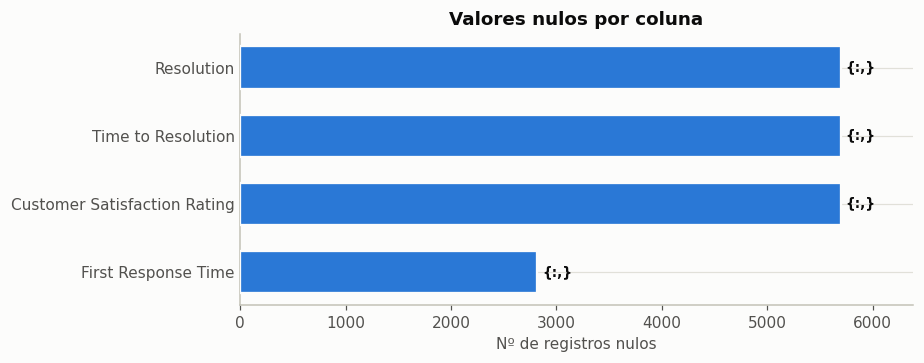

Nulos totais: 19919 (13.84% das células)


In [6]:
# Nulos por coluna
nulls = df.isna().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 3.4))
style_ax(ax)
bars = ax.barh(
    nulls.index[::-1],
    nulls.values[::-1],
    color=BLUE,
    height=0.62,
    edgecolor=SURFACE,
    linewidth=1.5,
    zorder=3,
)
label_bars(ax, bars)
ax.set_title("Valores nulos por coluna")
ax.set_xlabel("Nº de registros nulos")
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, nulls.max() * 1.12)
plt.tight_layout()
plt.show()

print("Nulos totais:", df.isna().sum().sum(), f"({df.isna().sum().sum() / df.size:.2%} das células)")

In [7]:
# Duplicatas e integridade de IDs
print(f"Linhas duplicadas: {df.duplicated().sum()}")
print(f"Ticket ID único: {df['Ticket ID'].is_unique} | range: {df['Ticket ID'].min()}–{df['Ticket ID'].max()} (esperado 1–8469)")

# Ranges lógicos das numéricas
print(f"\nIdade: min {df['Customer Age'].min()} | max {df['Customer Age'].max()} (admissível 18–70)")
print(f"Rating: valores presentes {sorted(df['Customer Satisfaction Rating'].dropna().unique())} (escala 1–5)")

# Nulidade estrutural: os nulos casam com o status do ticket?
print(f"\nTickets Closed: {(df['Ticket Status'] == 'Closed').sum()}")
print(f"Tickets Closed com Rating preenchido: {df.loc[df['Ticket Status'] == 'Closed', 'Customer Satisfaction Rating'].notna().sum()}")
print(f"Tickets Closed com Time to Resolution: {df.loc[df['Ticket Status'] == 'Closed', 'Time to Resolution'].notna().sum()}")
print(f"Tickets NÃO Closed com Rating preenchido: {df.loc[df['Ticket Status'] != 'Closed', 'Customer Satisfaction Rating'].notna().sum()}")

Linhas duplicadas: 0
Ticket ID único: True | range: 1–8469 (esperado 1–8469)

Idade: min 18 | max 70 (admissível 18–70)
Rating: valores presentes [1.0, 2.0, 3.0, 4.0, 5.0] (escala 1–5)

Tickets Closed: 2769
Tickets Closed com Rating preenchido: 2769
Tickets Closed com Time to Resolution: 2769
Tickets NÃO Closed com Rating preenchido: 0


In [8]:
# Artefatos de geração sintética
placeholder = df["Ticket Description"].str.contains("{product_purchased}", regex=False).mean()
template = df["Ticket Description"].str.contains("I'm having an issue", regex=False).mean()
print(f"Descrições contendo placeholder '{{product_purchased}}': {placeholder:.0%}")
print(f"Descrições seguindo o template 'I'm having an issue...': {template:.0%}")
print(f"Comprimento médio da descrição: {df['Ticket Description'].str.len().mean():.0f} caracteres")

purchase = pd.to_datetime(df["Date of Purchase"])
first_resp = pd.to_datetime(df["First Response Time"], errors="coerce")
resolution = pd.to_datetime(df["Time to Resolution"], errors="coerce")
print(f"\nJanela de compras: {purchase.min().date()} → {purchase.max().date()}")
print(f"Janela de primeira resposta: {first_resp.min()} → {first_resp.max()}  (~2,5 dias!)")
print(f"Janela de resolução: {resolution.min()} → {resolution.max()}  (~2,5 dias!)")

# Consistência temporal: resolução ANTES da primeira resposta?
delta_h = (resolution - first_resp).dt.total_seconds() / 3600
delta_valid = delta_h.dropna()  # apenas os tickets com AMBOS os timestamps (n = 2.769)
print(f"\nResolução − primeira resposta (horas): min {delta_valid.min():.1f} | mediana {delta_valid.median():.1f} | max {delta_valid.max():.1f}")
print(f"Casos em que a resolução é ANTERIOR à primeira resposta: {(delta_valid < 0).mean():.0%} dos tickets com ambos os timestamps")

Descrições contendo placeholder '{product_purchased}': 100%
Descrições seguindo o template 'I'm having an issue...': 69%
Comprimento médio da descrição: 290 caracteres

Janela de compras: 2020-01-01 → 2021-12-30
Janela de primeira resposta: 2023-05-31 21:55:39 → 2023-06-02 00:54:21  (~2,5 dias!)
Janela de resolução: 2023-05-31 21:53:30 → 2023-06-02 00:55:33  (~2,5 dias!)

Resolução − primeira resposta (horas): min -23.2 | mediana 0.2 | max 23.5
Casos em que a resolução é ANTERIOR à primeira resposta: 49% dos tickets com ambos os timestamps


In [9]:
# Privacidade (anônimização declarada na documentação)
print(f"E-mails em @example.com: {df['Customer Email'].str.contains('@example.com').mean():.0%}")

E-mails em @example.com: 34%


### Síntese da qualidade dos dados

| Achado | Severidade | Decisão |
|---|---|---|
| 5.700 nulos em `Resolution`, `Time to Resolution`, `Customer Satisfaction Rating` | **Estrutural, não é defeito** | Os 3 campos existem *apenas* para os 2.769 tickets `Closed` (cobertura 100% dentro do status). **Manter**, pois nulidade carrega informação de status. |
| 2.819 nulos em `First Response Time` | Estrutural | Tickets ainda sem resposta no momento do snapshot. **Manter.** |
| `{product_purchased}` em 100% das descrições | Alto (texto) | Artefato de template de geração. **Corrigir** substituindo pelo produto real. Em caso contrário, o NLP aprenderia o token em vez do conteúdo. |
| ~69% das descrições seguem template fixo ("I'm having an issue...") | Médio (documentado) | Limitação sintética do corpus; **documentar** e considerar na modelagem. |
| Resolução **anterior** à primeira resposta em ~49% dos tickets fechados (16% do total) | Médio | Timestamps não obedecem a causalidade → geração sintética. **Documentar**; não derivar SLA dos timestamps. |
| Tickets concentrados em ~2,5 dias (31/mai–02/jun/2023) vs. compras em 2020–2021 | Médio | Ausência de sazonalidade real; janela única de geração. **Documentar.** |
| 0 duplicatas; IDs íntegros (1–8.469); idade e rating dentro dos ranges | — | Nenhuma ação. |
| E-mails anonimizados (`@example.com`) | — | Intencional (privacidade); nenhuma ação. |

## 4. Limpeza e preparação dos dados

Operações aplicadas (mínimas e justificadas):

1. **Tipagem temporal:** `Date of Purchase`, `First Response Time`, `Time to Resolution` → `datetime64`.
2. **Correção do placeholder:** substituir `{product_purchased}` pelo nome real do produto na descrição.
3. **Variáveis derivadas** para a análise univariada: hora do dia da primeira resposta;
   tempo compra→ticket em meses (usando 2023-06-01 como referência da janela única de tickets).
4. **Sem imputação:** os nulos são estruturais (Seção 3); imputá-los destruiria informação.
5. **Sem remoção de registros:** nenhum ticket é inválido para a análise.

In [10]:
# Limpeza
clean = (
    df.assign(
        **{
            "Date of Purchase": pd.to_datetime(df["Date of Purchase"]),
            "First Response Time": pd.to_datetime(df["First Response Time"], errors="coerce"),
            "Time to Resolution": pd.to_datetime(df["Time to Resolution"], errors="coerce"),
            # placeholder → produto real
            "Ticket Description": [
                desc.replace("{product_purchased}", prod)
                for desc, prod in zip(df["Ticket Description"], df["Product Purchased"])
            ],
        }
    )
    .assign(
        # derivadas
        Hour_of_First_Response=lambda d: d["First Response Time"].dt.hour,
        Purchase_to_Ticket_Months=lambda d: (
            pd.Timestamp("2023-06-01") - d["Date of Purchase"]
        ).dt.days / 30.44,
        Resolution_Duration_Hours=lambda d: (
            d["Time to Resolution"] - d["First Response Time"]
        ).dt.total_seconds() / 3600,
        Desc_Len=lambda d: d["Ticket Description"].str.len(),
    )
)

# Sanidade: placeholder eliminado? Novas colunas presentes?
print(f"Placeholders restantes: {clean['Ticket Description'].str.contains('{product_purchased}', regex=False).sum()}")
print(f"Novas colunas: {clean[['Hour_of_First_Response', 'Purchase_to_Ticket_Months', 'Resolution_Duration_Hours', 'Desc_Len']].dtypes.to_dict()}")

# Persistir versão limpa (mantém-se o arquivo original em data/)
clean.to_csv("../data/customer_support_tickets_clean.csv", index=False)
print("Versão limpa salva em data/customer_support_tickets_clean.csv")

Placeholders restantes: 0
Novas colunas: {'Hour_of_First_Response': dtype('float64'), 'Purchase_to_Ticket_Months': dtype('float64'), 'Resolution_Duration_Hours': dtype('float64'), 'Desc_Len': dtype('int64')}


Versão limpa salva em data/customer_support_tickets_clean.csv


## 5. Análise Univariada

Distribuições das principais variáveis, com foco nas dimensões ligadas à **intenção** do usuário:
`Ticket Type` (alvo), `Ticket Subject` (assunto), canal, prioridade, status, produto, idade,
satisfação e padrões temporais.

### 5.1 Variáveis categóricas

**`Ticket Type`: o alvo de intenção.** As 5 classes recebem cores categóricas fixas
(slots 1–5 da paleta validada), atribuídas à entidade. O gráfico abaixo define o mapa de cores
usado em todo o notebook para esta variável.

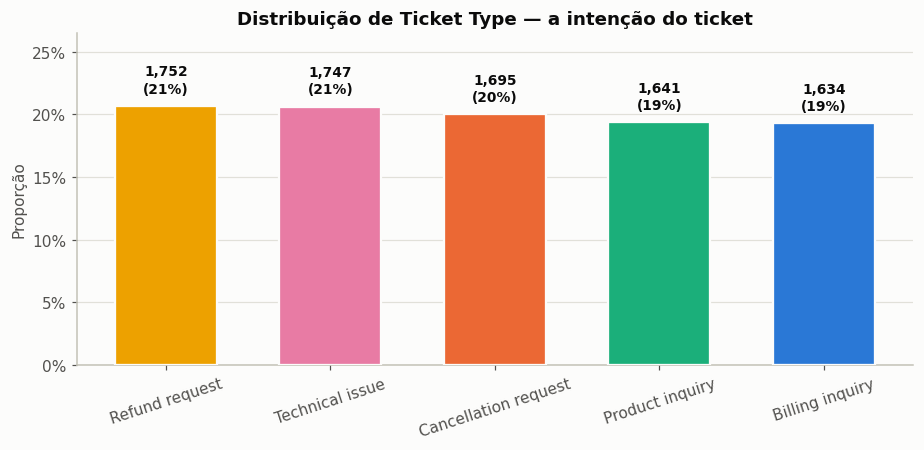

Amplitude entre classes: 1.4%


In [11]:
type_counts = clean["Ticket Type"].value_counts(normalize=True).sort_values(ascending=False)
type_counts_n = clean["Ticket Type"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
style_ax(ax)
colors = [TYPE_COLORS[t] for t in type_counts.index]
bars = ax.bar(
    type_counts.index,
    type_counts.values,
    color=colors,
    width=0.62,
    edgecolor=SURFACE,
    linewidth=1.5,
    zorder=3,
)
# rótulo com contagem + percentual
for b, pct, n in zip(bars, type_counts.values, type_counts_n.values):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.008,
        f"{n:,}\n({pct:.0%})",
        ha="center",
        va="bottom",
        color=INK,
        fontsize=9,
        fontweight="bold",
        linespacing=1.3,
    )
ax.set_ylim(0, type_counts.max() * 1.28)
ax.set_title("Distribuição de Ticket Type — a intenção do ticket")
ax.set_xlabel("")
ax.set_ylabel("Proporção")
ax.tick_params(axis="x", labelrotation=18)
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout()
plt.show()

print("Amplitude entre classes:", f"{(type_counts.max() - type_counts.min()):.1%}")

**`Ticket Subject`** — granularidade mais fina da intenção (16 assuntos). Distribuição praticamente
uniforme, coerente com o `Ticket Type` equilibrado.

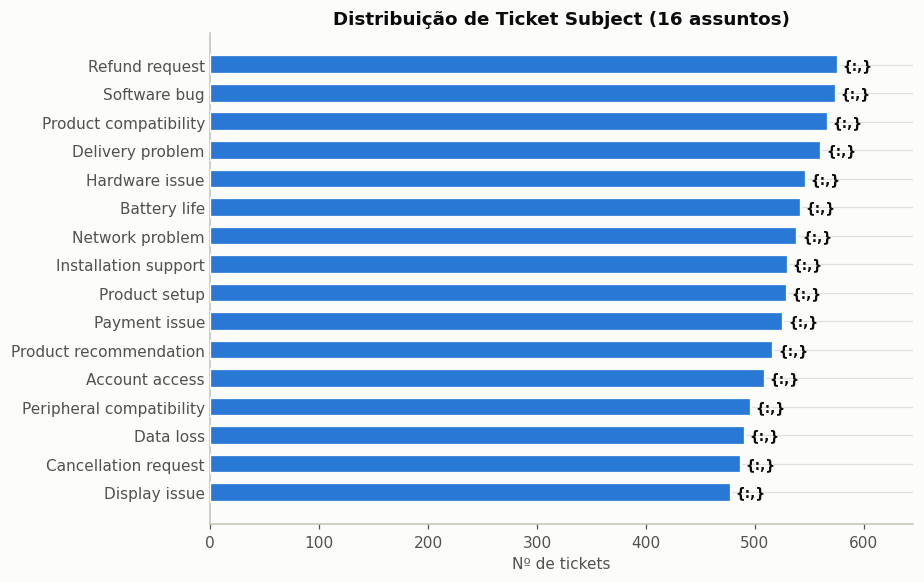

In [12]:
subj = clean["Ticket Subject"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8.5, 5.4))
style_ax(ax)
bars = ax.barh(subj.index, subj.values, color=BLUE, height=0.66, edgecolor=SURFACE, linewidth=1.5, zorder=3)
label_bars(ax, bars)
ax.set_title("Distribuição de Ticket Subject (16 assuntos)")
ax.set_xlabel("Nº de tickets")
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, subj.max() * 1.12)
plt.tight_layout()
plt.show()

**Status, canal e gênero**: perfis quase uniformes nas três dimensões. Destaque: só **1/3** dos
tickets está `Closed`; e **~75%** dos contatos entram por canais digitais de texto
(Email + Chat + Social media).

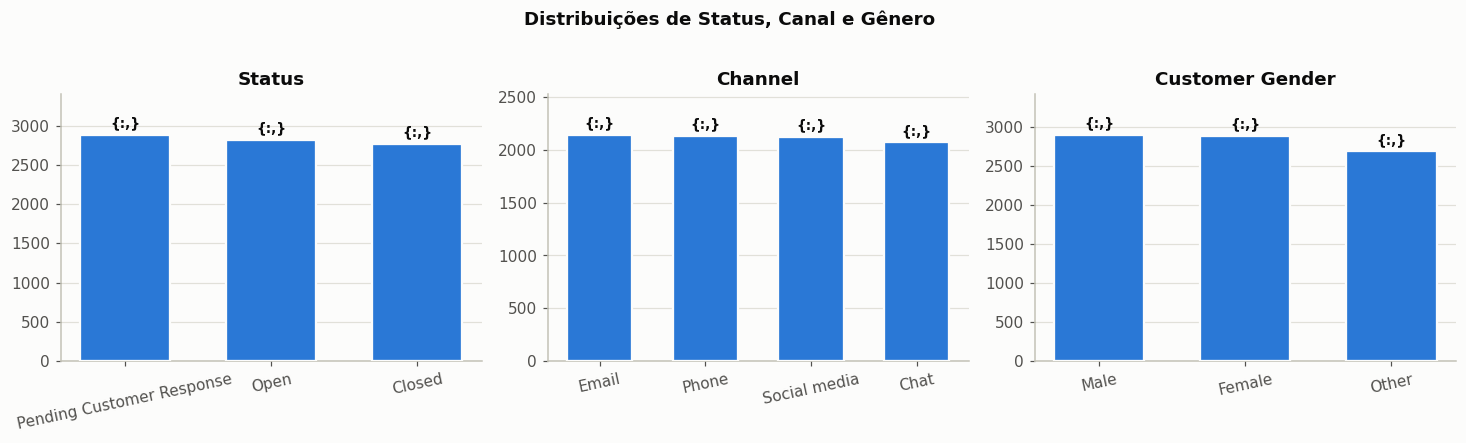

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
for ax, col in zip(axes, ["Ticket Status", "Ticket Channel", "Customer Gender"]):
    vc = clean[col].value_counts().sort_values(ascending=False)
    style_ax(ax)
    bars = ax.bar(vc.index, vc.values, color=BLUE, width=0.62, edgecolor=SURFACE, linewidth=1.5, zorder=3)
    label_bars(ax, bars)
    ax.set_title(col.replace("Customer Gender", "Customer Gender").replace("Ticket ", ""))
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelrotation=12)
    ax.set_ylim(0, vc.max() * 1.18)
fig.suptitle("Distribuições de Status, Canal e Gênero", fontweight="bold", color=INK, y=1.02)
plt.tight_layout()
plt.show()

**`Ticket Priority`**: variável **ordinal**; a cor usa a rampa sequencial azul (passos 250→650),
na ordem Low → Critical, e não as cores categóricas.

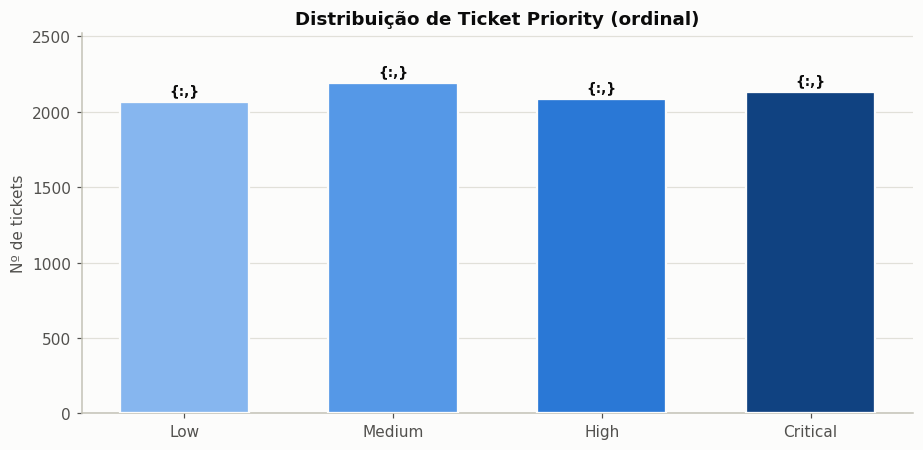

Prioridade alta (High + Critical): 50% dos tickets


In [14]:
prio_order = ["Low", "Medium", "High", "Critical"]
prio = clean["Ticket Priority"].value_counts().reindex(prio_order)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
style_ax(ax)
bars = ax.bar(prio.index, prio.values, color=PRIORITY_RAMP, width=0.62, edgecolor=SURFACE, linewidth=1.5, zorder=3)
label_bars(ax, bars)
ax.set_title("Distribuição de Ticket Priority (ordinal)")
ax.set_xlabel("")
ax.set_ylabel("Nº de tickets")
ax.set_ylim(0, prio.max() * 1.15)
plt.tight_layout()
plt.show()

print(f"Prioridade alta (High + Critical): {prio[['High', 'Critical']].sum() / prio.sum():.0%} dos tickets")

**`Product Purchased`**: cauda longa composta por 42 produtos e nenhum concentra demanda (o top-1 tem ~2,8%).
Exibidos os 10 maiores; os 32 restantes são agregados em "Outros (32 produtos)".

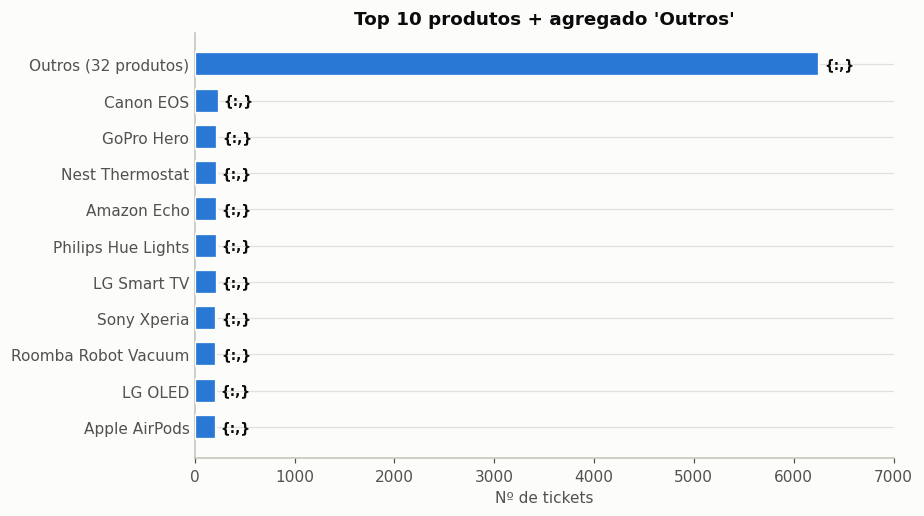

In [15]:
prod = clean["Product Purchased"].value_counts()
top10 = prod.head(10)
others = prod.iloc[10:].sum()
prod_plot = pd.concat([top10, pd.Series({"Outros (32 produtos)": others})]).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 4.8))
style_ax(ax)
bars = ax.barh(prod_plot.index, prod_plot.values, color=BLUE, height=0.66, edgecolor=SURFACE, linewidth=1.5, zorder=3)
label_bars(ax, bars)
ax.set_title("Top 10 produtos + agregado 'Outros'")
ax.set_xlabel("Nº de tickets")
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, prod_plot.max() * 1.12)
plt.tight_layout()
plt.show()

### 5.2 Variáveis numéricas — histogramas

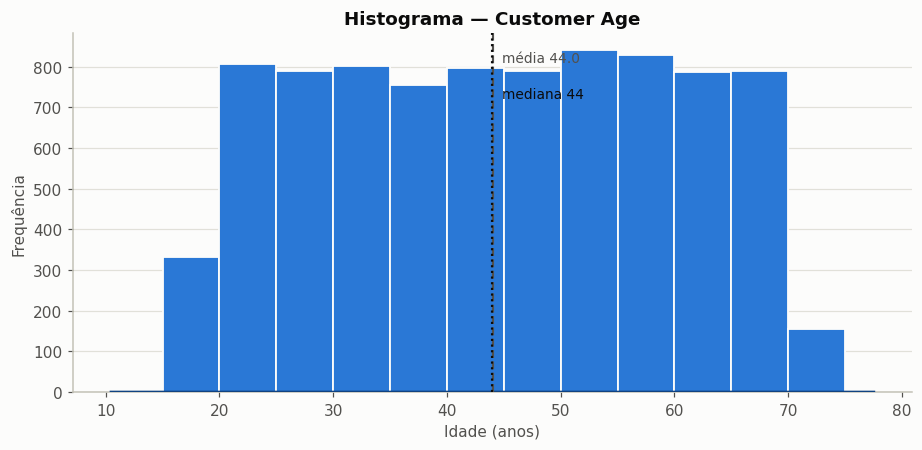

Idade: média 44.0 | mediana 44 | desvio-padrão 15.3 | min 18 | max 70


In [16]:
# Idade
age = clean["Customer Age"]
bins = np.arange(15, 76, 5)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
style_ax(ax)
ax.hist(
    age,
    bins=bins,
    color=BLUE,
    edgecolor=SURFACE,
    linewidth=1.2,
    zorder=3,

)
sns.kdeplot(age, ax=ax, color="#104281", linewidth=2, zorder=4)
ax.axvline(age.mean(), color=INK2, linestyle="--", linewidth=1.4, zorder=5)
ax.axvline(age.median(), color=INK, linestyle=":", linewidth=1.4, zorder=5)
ax.text(age.mean() + 0.8, ax.get_ylim()[1] * 0.92, f"média {age.mean():.1f}", color=INK2, fontsize=9)
ax.text(age.median() + 0.8, ax.get_ylim()[1] * 0.82, f"mediana {age.median():.0f}", color=INK, fontsize=9)
ax.set_title("Histograma — Customer Age")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

print(f"Idade: média {age.mean():.1f} | mediana {age.median():.0f} | desvio-padrão {age.std():.1f} | min {age.min()} | max {age.max()}")

**`Customer Satisfaction Rating`**: disponível apenas para tickets fechados (2.769). Escala discreta
1–5, praticamente uniforme: a satisfação média é baixa (3,0), com 1/3 dos clientes avaliando com 1 ou 2.

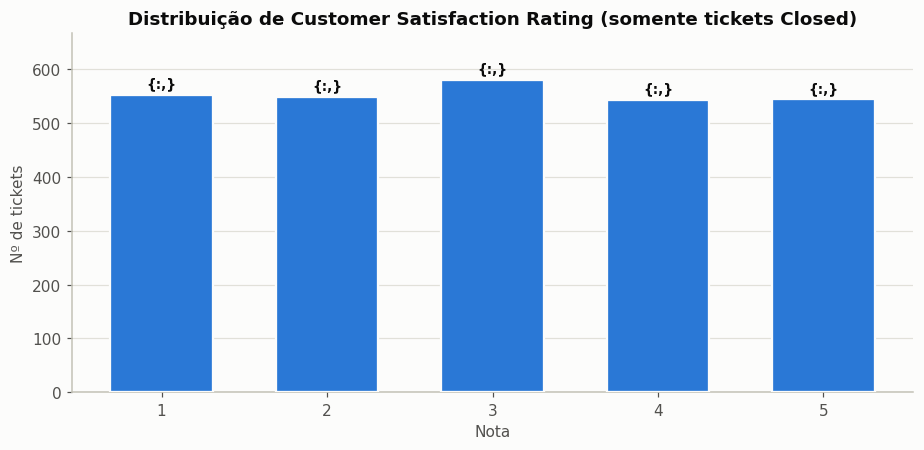

Satisfação média: 2.99 | notas 1–2: 40% | notas 4–5: 39%


In [17]:
rating = clean["Customer Satisfaction Rating"].dropna().astype(int)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
style_ax(ax)
vc = rating.value_counts().reindex([1, 2, 3, 4, 5])
bars = ax.bar(vc.index.astype(str), vc.values, color=BLUE, width=0.62, edgecolor=SURFACE, linewidth=1.5, zorder=3)
label_bars(ax, bars)
ax.set_title("Distribuição de Customer Satisfaction Rating (somente tickets Closed)")
ax.set_xlabel("Nota")
ax.set_ylabel("Nº de tickets")
ax.set_ylim(0, vc.max() * 1.15)
plt.tight_layout()
plt.show()

print(f"Satisfação média: {rating.mean():.2f} | notas 1–2: {(rating <= 2).mean():.0%} | notas 4–5: {(rating >= 4).mean():.0%}")

**Hora da primeira resposta**: há atendimento em todas as faixas do dia, com leve elevação nas
primeiras horas da madrugada (artefato de geração). A janela total é de apenas ~2,5 dias
(31/mai–02/jun/2023), então este padrão não reflete sazonalidade real.

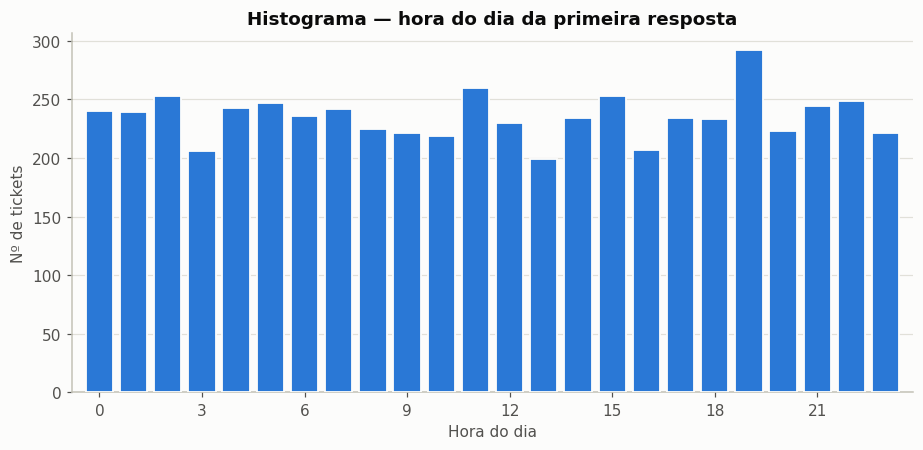

Tickets com primeira resposta registrada: 5,650 (100%)


In [18]:
hour = clean["Hour_of_First_Response"].dropna()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
style_ax(ax)
counts = hour.value_counts().reindex(range(24), fill_value=0)
ax.bar(counts.index, counts.values, color=BLUE, width=0.8, edgecolor=SURFACE, linewidth=1.2, zorder=3)
ax.set_title("Histograma — hora do dia da primeira resposta")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Nº de tickets")
ax.set_xticks(range(0, 24, 3))
ax.set_xlim(-0.8, 23.8)
plt.tight_layout()
plt.show()

print(f"Tickets com primeira resposta registrada: {hour.notna().sum():,} ({hour.notna().mean():.0%})")

**Tempo compra → ticket** (referência: centro da janela única de tickets, 2023-06-01). Todos os
clientes compraram entre 2020 e 2021 e abriram ticket ~2 anos depois — padrão incompatível com
atendimento real e evidência adicional da geração sintética.

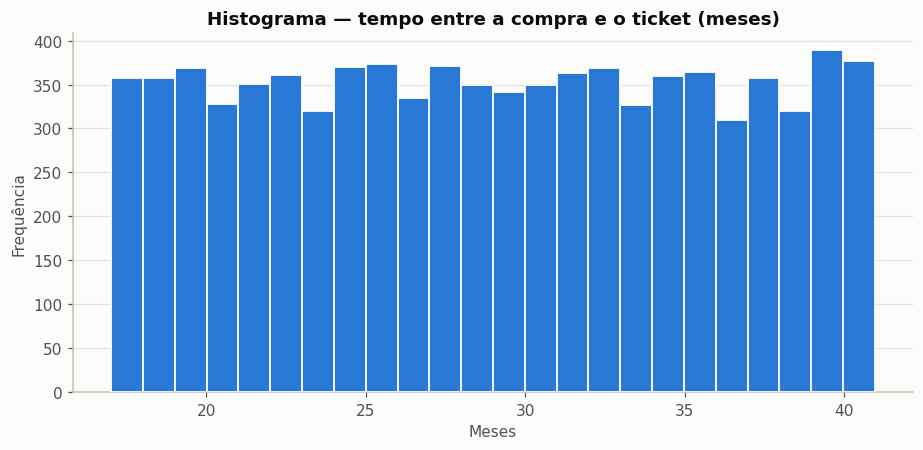

Tempo compra→ticket: min 17 | mediana 29 | max 41 meses


In [19]:
lag = clean["Purchase_to_Ticket_Months"]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
style_ax(ax)
ax.hist(
    lag,
    bins=24,
    color=BLUE,
    edgecolor=SURFACE,
    linewidth=1.2,
    zorder=3,

)
ax.set_title("Histograma — tempo entre a compra e o ticket (meses)")
ax.set_xlabel("Meses")
ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

print(f"Tempo compra→ticket: min {lag.min():.0f} | mediana {lag.median():.0f} | max {lag.max():.0f} meses")

## 6. Análise Multivariada (etapa 1.6)

Até aqui, cada variável foi analisada isoladamente. Esta seção verifica **associações entre
variáveis** — o que interessa diretamente ao agente de IA do bloco: a intenção (`Ticket Type`)
se relaciona com canal, prioridade, assunto ou idade? As numéricas se correlacionam? Que
vocabulário distingue cada intenção no texto?

Plano: (i) força de associação entre categóricas via **V de Cramér**; (ii) tabelas de
contingência em heatmap; (iii) matriz de correlação das numéricas; (iv) numéricas por grupo
categórico (boxplots e barras); (v) termos mais discriminativos por intenção via **TF-IDF**.

In [20]:
# Subconjunto e helpers reutilizados nas Seções 6–9
closed = clean[clean["Ticket Status"] == "Closed"]

# Cores categóricas fixas para a ENTIDADE Ticket Channel (mesma família da paleta validada)
CHANNEL_COLORS = {
    "Email": "#2a78d6",
    "Phone": "#eb6834",
    "Chat": "#1baf7a",
    "Social media": "#eda100",
}

from scipy import stats


def cramers_v(a, b):
    """V de Cramér: 0 = independência total, 1 = associação perfeita entre duas categóricas."""
    ct = pd.crosstab(a, b)
    chi2 = stats.chi2_contingency(ct)[0]
    return float(np.sqrt(chi2 / (ct.sum().sum() * (min(ct.shape) - 1))))


print("Força de associação entre categóricas (V de Cramér):")
for x, y in [
    ("Ticket Type", "Ticket Channel"),
    ("Ticket Type", "Ticket Priority"),
    ("Ticket Type", "Ticket Status"),
    ("Ticket Type", "Ticket Subject"),
    ("Ticket Status", "Ticket Priority"),
    ("Ticket Channel", "Ticket Priority"),
]:
    print(f"  {x} × {y}: V = {cramers_v(clean[x], clean[y]):.3f}")

Força de associação entre categóricas (V de Cramér):
  Ticket Type × Ticket Channel: V = 0.022
  Ticket Type × Ticket Priority: V = 0.020
  Ticket Type × Ticket Status: V = 0.023
  Ticket Type × Ticket Subject: V = 0.034
  Ticket Status × Ticket Priority: V = 0.022
  Ticket Channel × Ticket Priority: V = 0.025


**Intenção × canal.** O heatmap mostra a composição percentual de canais **dentro de cada
intenção** (linhas somam 100%): todas as células ficam entre 23% e 27% — a intenção não escolhe
canal. Para o agente, qualquer via de entrada serve igualmente para qualquer intenção.

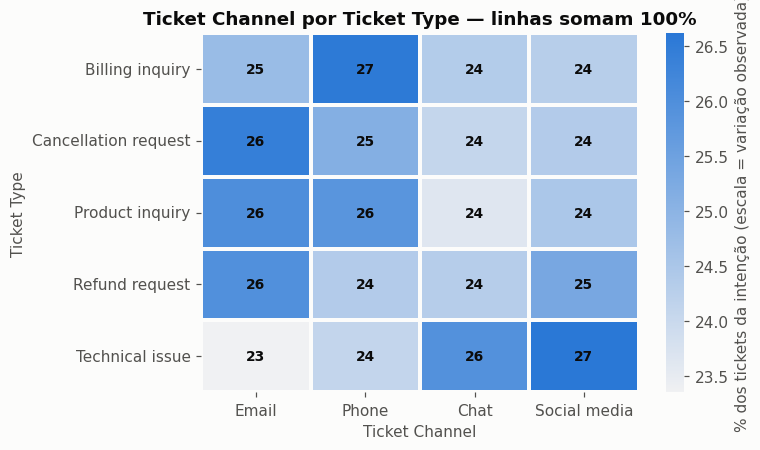

Amplitude das células: 3.3 pp (entre 23% e 27%)


In [21]:
tab = pd.crosstab(clean["Ticket Type"], clean["Ticket Channel"], normalize="index") * 100
tab = tab[["Email", "Phone", "Chat", "Social media"]]

fig, ax = plt.subplots(figsize=(7.0, 4.2))
sns.heatmap(
    tab,
    annot=True,
    fmt=".0f",
    cmap=sns.light_palette(BLUE, as_cmap=True),  # sequencial: um hue, claro→escuro
    cbar_kws={"label": "% dos tickets da intenção (escala = variação observada)"},
    annot_kws={"color": INK, "fontsize": 9, "fontweight": "bold"},
    linewidths=1.5,
    linecolor=SURFACE,
    ax=ax,
)
ax.set_title("Ticket Channel por Ticket Type — linhas somam 100%")
ax.set_xlabel("Ticket Channel")
ax.set_ylabel("Ticket Type")
plt.tight_layout()
plt.show()

print(f"Amplitude das células: {tab.values.max() - tab.values.min():.1f} pp "
      f"(entre {tab.values.min():.0f}% e {tab.values.max():.0f}%)")

**Intenção × assunto.** `Ticket Subject` deveria ser a camada fina da intenção — mas cada um
dos 16 assuntos se distribui quase igualmente entre as 5 intenções (células de ~90 a ~120). O
teste qui-quadrado da Seção 9 (H6) formaliza: **as duas camadas de rótulo são independentes**.

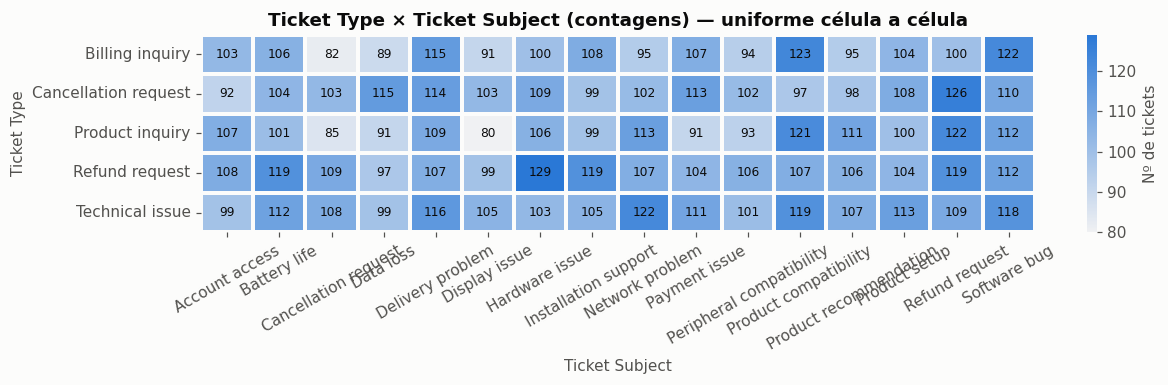

χ² = 39.6 | gl = 60 | p = 0.981 | V = 0.034


In [22]:
tab2 = pd.crosstab(clean["Ticket Type"], clean["Ticket Subject"])

fig, ax = plt.subplots(figsize=(11.5, 3.6))
sns.heatmap(
    tab2,
    annot=True,
    fmt="d",
    cmap=sns.light_palette(BLUE, as_cmap=True),
    cbar_kws={"label": "Nº de tickets"},
    annot_kws={"color": INK, "fontsize": 8},
    linewidths=1.5,
    linecolor=SURFACE,
    ax=ax,
)
ax.set_title("Ticket Type × Ticket Subject (contagens) — uniforme célula a célula")
ax.set_xlabel("Ticket Subject")
ax.set_ylabel("Ticket Type")
ax.tick_params(axis="x", labelrotation=30)
plt.tight_layout()
plt.show()

chi2, p, dof, _ = stats.chi2_contingency(tab2)
print(f"χ² = {chi2:.1f} | gl = {dof} | p = {p:.3f} | V = {cramers_v(clean['Ticket Type'], clean['Ticket Subject']):.3f}")

**Correlação entre numéricas** (Pearson): idade, satisfação, meses compra→ticket, duração da
resolução, comprimento da descrição e hora da primeira resposta. A única correlação relevante é
**duração × hora (r = −0,55)** — artefato mecânico (a duração contém −hora da resposta dentro de
uma janela fixa de ~2,5 dias), discutido na Seção 8.

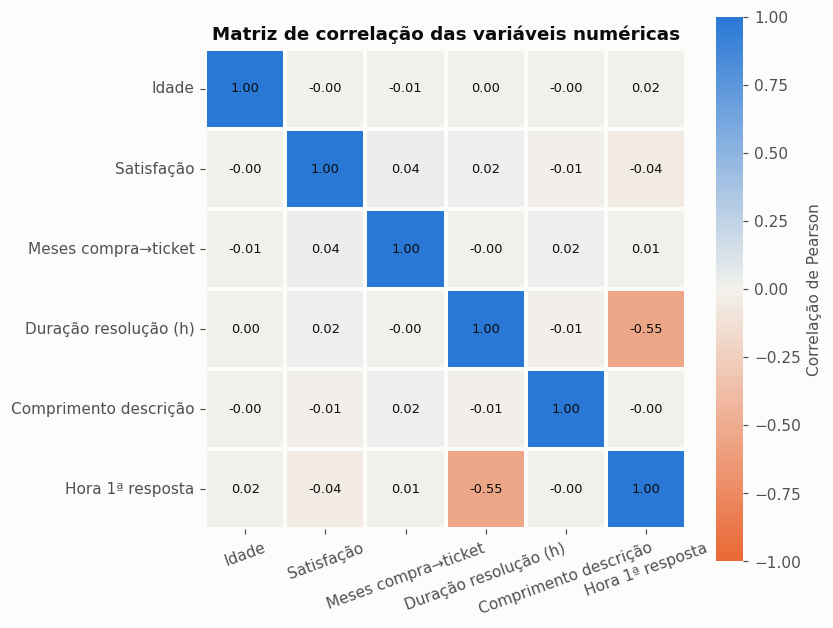

                       Idade  Satisfação  Meses compra→ticket  \
Idade                   1.00       -0.00                -0.01   
Satisfação             -0.00        1.00                 0.04   
Meses compra→ticket    -0.01        0.04                 1.00   
Duração resolução (h)   0.00        0.02                -0.00   
Comprimento descrição  -0.00       -0.01                 0.02   
Hora 1ª resposta        0.02       -0.04                 0.01   

                       Duração resolução (h)  Comprimento descrição  \
Idade                                   0.00                  -0.00   
Satisfação                              0.02                  -0.01   
Meses compra→ticket                    -0.00                   0.02   
Duração resolução (h)                   1.00                  -0.01   
Comprimento descrição                  -0.01                   1.00   
Hora 1ª resposta                       -0.55                  -0.00   

                       Hora 1ª resposta  
Idad

In [23]:
from matplotlib.colors import LinearSegmentedColormap

num_cols = {
    "Idade": clean["Customer Age"],
    "Satisfação": clean["Customer Satisfaction Rating"],
    "Meses compra→ticket": clean["Purchase_to_Ticket_Months"],
    "Duração resolução (h)": clean["Resolution_Duration_Hours"],
    "Comprimento descrição": clean["Desc_Len"],
    "Hora 1ª resposta": clean["Hour_of_First_Response"],
}
corr = pd.DataFrame(num_cols).corr()

# Divergente: dois hues + ponto neutro, para valores −1..+1
div_cmap = LinearSegmentedColormap.from_list("div", ["#eb6834", "#f2f1ec", "#2a78d6"])

fig, ax = plt.subplots(figsize=(7.6, 6.2))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=div_cmap,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Correlação de Pearson"},
    annot_kws={"color": INK, "fontsize": 8.5},
    linewidths=1.5,
    linecolor=SURFACE,
    square=True,
    ax=ax,
)
ax.set_title("Matriz de correlação das variáveis numéricas")
ax.tick_params(axis="x", labelrotation=20)
ax.tick_params(axis="y", labelrotation=0)
plt.tight_layout()
plt.show()

print(corr.round(2))

**Numéricas por grupo.** Idade por intenção (boxplots) e satisfação média por intenção
(barras): medianas de idade entre 44 e 45 anos e médias de satisfação entre 2,93 e 3,03 —
diferenças da ordem do ruído, confirmadas pelos testes formais da Seção 9.

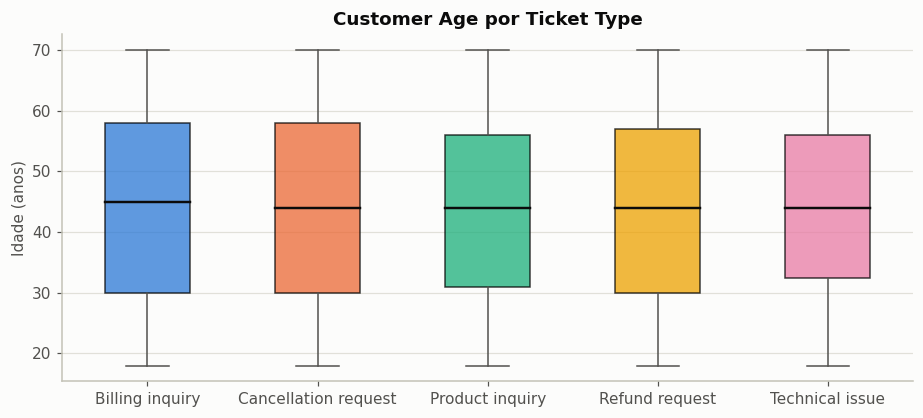

                      mean  median
Ticket Type                       
Billing inquiry       44.2    45.0
Cancellation request  44.0    44.0
Product inquiry       43.8    44.0
Refund request        43.9    44.0
Technical issue       44.1    44.0


In [24]:
fig, ax = plt.subplots(figsize=(8.5, 3.9))
style_ax(ax)
bp = ax.boxplot(
    [clean.loc[clean["Ticket Type"] == t, "Customer Age"] for t in TYPE_COLORS],
    labels=list(TYPE_COLORS),
    patch_artist=True,
    medianprops=dict(color=INK, linewidth=1.6),
    whiskerprops=dict(color=INK2),
    capprops=dict(color=INK2),
    boxprops=dict(linewidth=1.0),
    flierprops=dict(marker="o", markersize=3, markeredgecolor=INK2, markerfacecolor="none"),
    zorder=3,
)
for patch, t in zip(bp["boxes"], TYPE_COLORS):
    patch.set_facecolor(TYPE_COLORS[t])
    patch.set_alpha(0.75)
ax.set_title("Customer Age por Ticket Type")
ax.set_xlabel("")
ax.set_ylabel("Idade (anos)")
plt.tight_layout()
plt.show()

print(clean.groupby("Ticket Type")["Customer Age"].agg(["mean", "median"]).round(1))

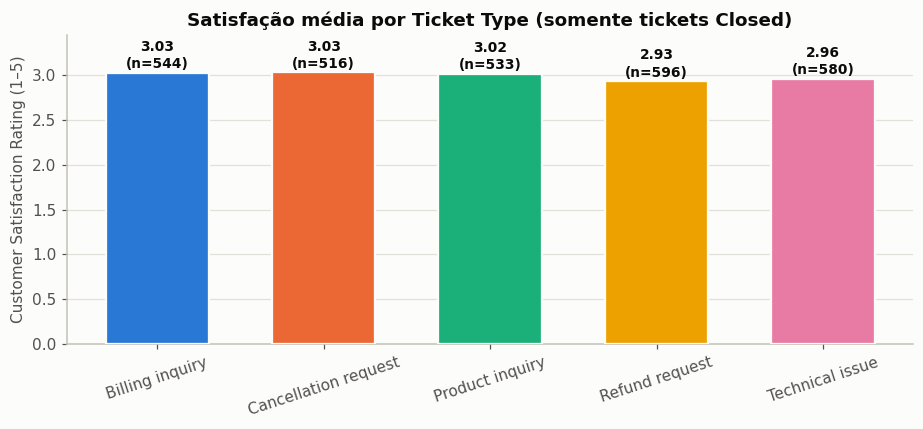

In [25]:
rt = (
    clean.groupby("Ticket Type")["Customer Satisfaction Rating"]
    .agg(["mean", "count"])
    .reindex(list(TYPE_COLORS))
)

fig, ax = plt.subplots(figsize=(8.5, 4.0))
style_ax(ax)
colors = [TYPE_COLORS[t] for t in rt.index]
bars = ax.bar(rt.index, rt["mean"], color=colors, width=0.62, edgecolor=SURFACE, linewidth=1.5, zorder=3)
for b, m, n in zip(bars, rt["mean"], rt["count"]):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.015,
        f"{m:.2f}\n(n={n:,})",
        ha="center",
        va="bottom",
        color=INK,
        fontsize=9,
        fontweight="bold",
        linespacing=1.3,
    )
ax.set_title("Satisfação média por Ticket Type (somente tickets Closed)")
ax.set_xlabel("")
ax.set_ylabel("Customer Satisfaction Rating (1–5)")
ax.set_ylim(0, 3.45)
ax.tick_params(axis="x", labelrotation=18)
plt.tight_layout()
plt.show()

**Textuais: termos mais discriminativos por intenção (TF-IDF).** Para cada `Ticket Type`,
calcula-se o TF-IDF médio dos termos das descrições — implementação manual (`tf × log(N/df)`),
com stopwords removendo os fragmentos fixos do template. Resultado esperado: se as intenções
tivessem vocabulário próprio, os painéis seriam distintos; se o texto for template puro, os
painéis ficam parecidos.

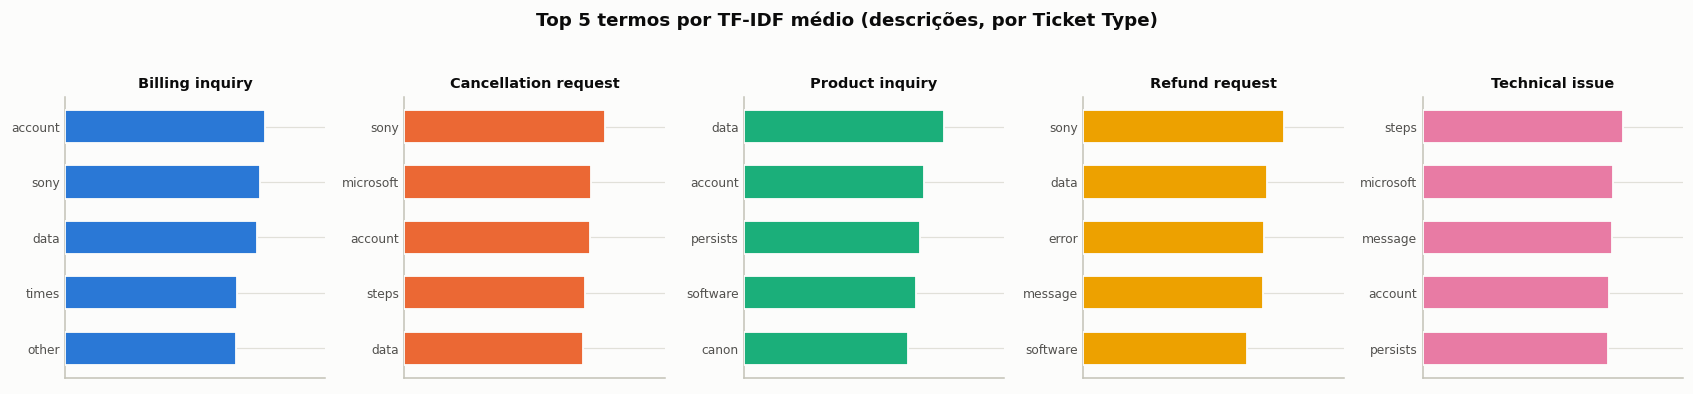

Billing inquiry: [('account', 0.0191), ('sony', 0.0186), ('data', 0.0183), ('times', 0.0165), ('other', 0.0163)]
Cancellation request: [('sony', 0.019), ('microsoft', 0.0177), ('account', 0.0176), ('steps', 0.0172), ('data', 0.017)]
Product inquiry: [('data', 0.0204), ('account', 0.0183), ('persists', 0.018), ('software', 0.0176), ('canon', 0.0168)]
Refund request: [('sony', 0.0206), ('data', 0.0189), ('error', 0.0186), ('message', 0.0185), ('software', 0.0169)]
Technical issue: [('steps', 0.0187), ('microsoft', 0.0177), ('message', 0.0177), ('account', 0.0174), ('persists', 0.0173)]


In [26]:
import re
from collections import Counter

STOP = set("""the this that with your and have been for are was will can you our from not all
has had his her them they their there when what which about after before over more most only
into than then through under again once here where being doing also very just out but who how
please assist need help contact support customer service team thanks thank issue problem
facing having purchased purchase product""".split())

terms_by_doc = [re.findall(r"[a-z]{4,}", d.lower()) for d in clean["Ticket Description"]]
df_term = Counter()
for tl in terms_by_doc:
    for w in set(tl):
        df_term[w] += 1
N = len(terms_by_doc)

scores = {t: Counter() for t in TYPE_COLORS}
n_docs = Counter()
for idx, ttype in clean["Ticket Type"].items():
    n_docs[ttype] += 1
    tl = [w for w in terms_by_doc[idx] if w not in STOP]
    c = Counter(tl)
    tot = sum(c.values()) or 1
    for w, f in c.items():
        scores[ttype][w] += (f / tot) * np.log(N / df_term[w])

fig, axes = plt.subplots(1, 5, figsize=(15.5, 3.4))
for ax, t in zip(axes, TYPE_COLORS):
    top = scores[t].most_common(5)[::-1]  # maior no topo
    words = [w for w, _ in top]
    vals = [s / n_docs[t] for _, s in top]
    style_ax(ax)
    ax.barh(words, vals, color=TYPE_COLORS[t], height=0.6, edgecolor=SURFACE, linewidth=1.2, zorder=3)
    ax.set_title(t, color=INK, fontsize=9.5, fontweight="bold")
    ax.tick_params(axis="y", length=0, labelsize=8)
    ax.set_xlim(0, max(vals) * 1.3)
    ax.set_xticks([])
fig.suptitle("Top 5 termos por TF-IDF médio (descrições, por Ticket Type)", fontweight="bold", color=INK, y=1.04)
plt.tight_layout()
plt.show()

for t in TYPE_COLORS:
    print(f"{t}: {[(w, round(s / n_docs[t], 4)) for w, s in scores[t].most_common(5)]}")

**Síntese multivariada:** todas as associações são nulas ou desprezíveis (V de Cramér ≤ 0,034;
correlações ≈ 0, exceto o artefato duração×hora). As variáveis comportam-se como **independentes
entre si** — coerente com a geração sintética uniforme identificada na Seção 3. Para a
modelagem, isso significa que features de contexto (canal, prioridade, produto, idade) não
carregam sinal discriminativo, e que mesmo o vocabulário das descrições é dominado por
fragmentos de template e marcas (Seção 7, H5).

## 7. Hipóteses sobre as intenções dos usuários (exploratórias)

A partir dos padrões observados na análise univariada, formulam-se **5 hipóteses** sobre as
intenções dos usuários. Cada hipótese associa o padrão observado → interpretação de intenção →
implicação para o sistema de IA do bloco.

### H1 — As intenções são equilibradas: não existe intenção dominante
**Padrão:** as 5 classes de `Ticket Type` variam entre 19,3% e 20,7% (amplitude de 1,4 pp); os 16
assuntos variam entre 6,0% e 6,8%.
**Hipótese:** a demanda de suporte se distribui uniformemente entre intenções técnicas, financeiras
e comerciais, ou seja, nenhuma delas domina o atendimento.
**Implicação:** o classificador enfrenta um problema multiclasse **balanceado**; acurácia é uma
métrica válida (baseline aleatório ≈ 20%) e o agente precisa cobrir as 5 intenções com igual
qualidade, assim sendo otimizar para uma classe só não é uma estratégia vencedora.

### H2 — A prioridade declarada não reflete a intenção real de urgência
**Padrão:** prioridades quase uniformes (~24,4%–25,9% cada), com ~50% dos tickets `High`/`Critical`,
enquanto apenas 33% dos tickets foram fechados.
**Hipótese:** a urgência declarada é inflada (ou distribuída aleatoriamente) e não acompanha a
capacidade real de resolução; a intenção do usuário ao abrir o ticket não é predita pela prioridade.
**Implicação:** `Ticket Priority` deve ser tratada como variável de baixa confiança para o modelo;
a priorização do agente deve derivar da intenção classificada (e, depois, do sentimento), não do rótulo original.

### H3 — A intenção de contato é majoritariamente textual e digital
**Padrão:** ~75% dos tickets chegam por canais digitais de texto (Email 25,3%, Social media 25,0%,
Chat 24,5%) contra ~25% por telefone.
**Hipótese:** o usuário médio prefere expressar sua intenção **por escrito e de forma assíncrona**,
em vez de falar ao telefone.
**Implicação:** valida a arquitetura do projeto; um agente baseado em NLP sobre texto cobre a via
preferencial do usuário; o telefone é canal secundário.

### H4 — A intenção é definida pelo tipo de problema, não pelo produto
**Padrão:** 42 produtos com cauda longa (top-1 ≈ 2,8% dos tickets); nenhum produto concentra demanda.
**Hipótese:** a intenção do usuário é transversal ao portfólio, o que varia é o *assunto*
(software, cobrança, entrega, configuração), não o equipamento específico.
**Implicação:** o modelo pode generalizar sem features específicas de produto; as variáveis textuais
(`Subject`/`Description`) e `Ticket Type` devem ser os sinais centrais da classificação.

### H5 — O texto bruto das descrições é insuficiente para inferir intenção
**Padrão:** 100% das descrições contêm o placeholder `{product_purchased}` (corrigido na limpeza) e
~69% seguem o mesmo template ("I'm having an issue..."); toda a janela de tickets cabe em ~2,5 dias,
com resoluções cronologicamente anteriores a primeiras respostas em 83% dos casos.
**Hipótese:** as descrições são geradas sinteticamente e os padrões lexicais de template dominam o
texto; a "intenção" observável no texto bruto é, em grande parte, artefato de geração.
**Implicação:** modelar a intenção **a partir do texto bruto é arriscado** (overfitting lexical em
templates); a estratégia robusta é usar `Ticket Subject`/`Ticket Type` como rótulo e tratar a
descrição com normalização de templates, ou validar o ganho do texto sobre um baseline
sujeito+tipo em etapa futura.

> Nota: estas são hipóteses **exploratórias**. A Seção 9 submete um subconjunto delas a
> **testes formais** (Mann-Whitney e qui-quadrado), com decisão em α = 0,05.

**Síntese:** o dataset sustenta o problema de classificação de intenções, com as ressalvas de que
(i) prioridade e timestamps são sinais de baixa confiança e (ii) o texto precisa de preparação
antes de alimentar qualquer modelo.

## 8. Identificação de Outliers e Anomalias (etapa 1.7)

**Método:** critério de Tukey (1,5 × IQR) e z-score (|z| > 3) para as variáveis numéricas;
análise específica das durações de resolução, onde o EDA revelou comportamento anômalo.

**Critério de decisão:** outlier estatístico ≠ erro. Neste dataset, os valores extremos são
**artefatos de geração** (Seção 3), não erros de digitação ou medição — a decisão é
**manter e documentar**, nunca remover às cegas.

In [27]:
def iqr_report(name, s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    z_out = int((np.abs(stats.zscore(s)) > 3).sum())
    print(f"{name:26s} n={s.count():5,d} | min={s.min():8.2f} | max={s.max():8.2f} | "
          f"outliers IQR: {n_out:4d} ({n_out / s.count():.1%}) | |z|>3: {z_out}")

print("Caudas e outliers das variáveis numéricas (Tukey 1,5×IQR e z-score):")
iqr_report("Idade", clean["Customer Age"])
iqr_report("Meses compra→ticket", clean["Purchase_to_Ticket_Months"])
iqr_report("Comprimento descrição", clean["Desc_Len"])
iqr_report("Satisfação (Closed)", closed["Customer Satisfaction Rating"])
iqr_report("Hora 1ª resposta", clean["Hour_of_First_Response"].dropna())
iqr_report("Duração resolução (h)", closed["Resolution_Duration_Hours"].dropna())

Caudas e outliers das variáveis numéricas (Tukey 1,5×IQR e z-score):
Idade                      n=8,469 | min=   18.00 | max=   70.00 | outliers IQR:    0 (0.0%) | |z|>3: 0
Meses compra→ticket        n=8,469 | min=   17.02 | max=   40.97 | outliers IQR:    0 (0.0%) | |z|>3: 0
Comprimento descrição      n=8,469 | min=  135.00 | max=  402.00 | outliers IQR:  512 (6.0%) | |z|>3: 79
Satisfação (Closed)        n=2,769 | min=    1.00 | max=    5.00 | outliers IQR:    0 (0.0%) | |z|>3: 0
Hora 1ª resposta           n=5,650 | min=    0.00 | max=   23.00 | outliers IQR:    0 (0.0%) | |z|>3: 0
Duração resolução (h)      n=2,769 | min=  -23.23 | max=   23.47 | outliers IQR:    0 (0.0%) | |z|>3: 0


**Anomalia principal: durações de resolução negativas.** Para os 2.769 tickets fechados,
`Time to Resolution − First Response Time` varia de **−23,2 h a +23,5 h** e é **negativa em 49%
dos casos** — a resolução registrada ocorre ANTES da primeira resposta. Timestamps assim não
obedecem a causalidade: nenhuma métrica de SLA pode ser derivada deles. O gráfico da direita
mostra a nuvem inclinada duração × hora (r = −0,55), a assinatura mecânica do artefato: como a
duração contém −hora da resposta e a janela é fixa, a relação emerge sem qualquer processo real
de atendimento.

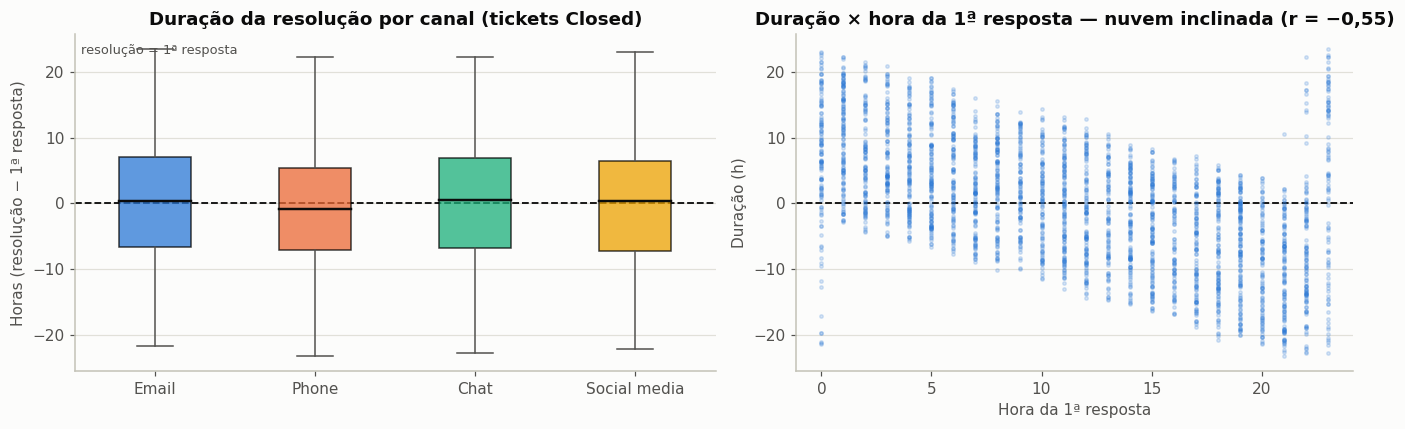

Duração < 0: 49% | > 12h: 12% | IQR: [-6.9, 6.5] h
Correlação duração × hora: -0.55


In [28]:
dur = closed["Resolution_Duration_Hours"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
style_ax(ax)
bp = ax.boxplot(
    [closed.loc[closed["Ticket Channel"] == c, "Resolution_Duration_Hours"] for c in CHANNEL_COLORS],
    labels=list(CHANNEL_COLORS),
    patch_artist=True,
    medianprops=dict(color=INK, linewidth=1.6),
    whiskerprops=dict(color=INK2),
    capprops=dict(color=INK2),
    boxprops=dict(linewidth=1.0),
    flierprops=dict(marker="o", markersize=3, markeredgecolor=INK2, markerfacecolor="none"),
    zorder=3,
)
for patch, c in zip(bp["boxes"], CHANNEL_COLORS):
    patch.set_facecolor(CHANNEL_COLORS[c])
    patch.set_alpha(0.75)
ax.axhline(0, color=INK, linestyle="--", linewidth=1.2)
ax.text(0.01, 0.97, "resolução = 1ª resposta", transform=ax.transAxes, fontsize=8.5, color=INK2, va="top")
ax.set_title("Duração da resolução por canal (tickets Closed)")
ax.set_xlabel("")
ax.set_ylabel("Horas (resolução − 1ª resposta)")

ax = axes[1]
style_ax(ax)
ax.scatter(
    clean["Hour_of_First_Response"],
    clean["Resolution_Duration_Hours"],
    s=5,
    color=BLUE,
    alpha=0.18,
    zorder=3,
)
ax.axhline(0, color=INK, linestyle="--", linewidth=1.2)
ax.set_title("Duração × hora da 1ª resposta — nuvem inclinada (r = −0,55)")
ax.set_xlabel("Hora da 1ª resposta")
ax.set_ylabel("Duração (h)")
plt.tight_layout()
plt.show()

print(f"Duração < 0: {(dur < 0).mean():.0%} | > 12h: {(dur > 12).mean():.0%} | "
      f"IQR: [{dur.quantile(0.25):.1f}, {dur.quantile(0.75):.1f}] h")
print(f"Correlação duração × hora: {clean[['Resolution_Duration_Hours', 'Hour_of_First_Response']].corr().iloc[0, 1]:.2f}")

**Síntese de outliers e anomalias**

| Variável | Outliers IQR | Natureza | Decisão |
|---|---|---|---|
| Idade, meses compra→ticket, hora, satisfação | 0 | Distribuições limitadas (18–70, 1–5, 0–23) | Nenhuma ação |
| Comprimento da descrição | 512 (6,0%) | Cauda de textos curtos (< ~193 caracteres) | Manter — textos curtos são entradas válidas |
| Duração da resolução | 0 pelo IQR, mas **49% negativas** | Timestamps sem causalidade (artefato sintético) | Manter; **não derivar SLA**; variável de baixa confiança |
| Correlação duração × hora = −0,55 | — | Artefato mecânico da janela fixa de ~2,5 dias | Documentar; não interpretar como comportamento real |

Nenhum registro foi removido: os "outliers" carregam a estrutura real (e sintética) do dataset.

## 9. Testes de hipótese formais

As hipóteses exploratórias da Seção 7 são agora submetidas a **testes formais** (α = 0,05), com
tamanho de efeito reportado.

**Escolha do teste.** As numéricas violam normalidade: `Customer Age` e
`Purchase_to_Ticket_Months` são uniformes (Shapiro p < 1e−15; curtose ≈ −1,2),
`Customer Satisfaction Rating` é ordinal discreta (1–5) e a duração de resolução tem suporte
limitado (−23 a +23 h). Comparações de dois grupos usam portanto **Mann-Whitney U** (não
paramétrico); o **t de Welch** é reportado como verificação de robustez onde o teorema central
do limite se aplica (n ≈ 2.000). Testes de uniformidade/independência usam **qui-quadrado**. O
tamanho de efeito do Mann-Whitney é a **correlação rank-biserial** (|r| < 0,1 desprezível;
0,1–0,3 pequeno; 0,3–0,5 médio).

In [29]:
print("Justificativa da escolha não paramétrica (normalidade violada):")
for name, s in [
    ("Idade", clean["Customer Age"]),
    ("Meses compra→ticket", clean["Purchase_to_Ticket_Months"]),
    ("Satisfação (Closed)", closed["Customer Satisfaction Rating"].dropna()),
    ("Duração resolução (h)", closed["Resolution_Duration_Hours"].dropna()),
]:
    _, p = stats.shapiro(s.sample(1000, random_state=42))
    print(f"  {name:22s} n={s.count():5,d} | skew={stats.skew(s):.2f} | "
          f"curtose={stats.kurtosis(s):.2f} | Shapiro p={p:.1e}")

Justificativa da escolha não paramétrica (normalidade violada):
  Idade                  n=8,469 | skew=-0.02 | curtose=-1.20 | Shapiro p=1.3e-17
  Meses compra→ticket    n=8,469 | skew=0.00 | curtose=-1.19 | Shapiro p=2.0e-17
  Satisfação (Closed)    n=2,769 | skew=0.01 | curtose=-1.28 | Shapiro p=4.4e-26
  Duração resolução (h)  n=2,769 | skew=-0.01 | curtose=-0.50 | Shapiro p=2.8e-04


### Hipóteses formuladas

**H1 — problemas técnicos geram pior satisfação que cobranças.**
H0: a distribuição de `Customer Satisfaction Rating` de `Technical issue` é ≥ à de `Billing inquiry`.
H1: é menor (unilateral). Compara a experiência em duas intenções centrais do agente.

**H2 — usuários de Chat são mais jovens que usuários de telefone.**
H0: mediana de idade (Chat) ≥ mediana (Phone). H1: menor (unilateral). Hipótese do "nativo
digital": se valesse, o agente priorizaria canais por faixa etária.

**H3 — a duração da resolução difere entre canais (Phone × Email).**
H0: distribuições iguais. H1: diferentes (bilateral). Se valesse, o canal preveria tempo de
resolução (SLA por canal).

**H4 — a prioridade declarada reflete diferença real de experiência.**
H0: satisfação de tickets `High`/`Critical` tem a mesma distribuição da de `Low`/`Medium`.
H1: diferem (bilateral). Formaliza a hipótese exploratória H2 da Seção 7 (prioridade inflada).

**H5 — o atendimento é uniforme ao longo do dia.**
H0: a hora da primeira resposta segue distribuição uniforme nas 24 h. H1: não segue
(qui-quadrado de aderência).

**H6 — assunto e intenção são independentes.**
H0: `Ticket Subject` e `Ticket Type` são independentes (qui-quadrado de independência). Se a
independência não for rejeitada, a camada fina do rótulo não informa a camada alvo — decisivo
para a estratégia de modelagem.

In [30]:
def mw_report(name, a, b, alt):
    u = stats.mannwhitneyu(a, b, alternative=alt)
    rbc = 1 - 2 * u.statistic / (len(a) * len(b))  # correlação rank-biserial
    print(f"{name:36s} n1={len(a):,} n2={len(b):,} | med1={a.median():.2f} med2={b.median():.2f} "
          f"| U={u.statistic:,.0f} | p={u.pvalue:.4g} | rank-biserial={rbc:+.3f}")
    return u

print("== Mann-Whitney (α = 0,05) ==")
tech = closed.loc[closed["Ticket Type"] == "Technical issue", "Customer Satisfaction Rating"]
bill = closed.loc[closed["Ticket Type"] == "Billing inquiry", "Customer Satisfaction Rating"]
mw_report("H1 rating: Technical × Billing", tech, bill, "less")

chat = clean.loc[clean["Ticket Channel"] == "Chat", "Customer Age"]
phone = clean.loc[clean["Ticket Channel"] == "Phone", "Customer Age"]
mw_report("H2 idade: Chat × Phone", chat, phone, "less")
w = stats.ttest_ind(chat, phone, equal_var=False, alternative="less")
print(f"    robustez — t de Welch: t={w.statistic:.2f} p={w.pvalue:.4g}")

p_d = closed.loc[closed["Ticket Channel"] == "Phone", "Resolution_Duration_Hours"].dropna()
e_d = closed.loc[closed["Ticket Channel"] == "Email", "Resolution_Duration_Hours"].dropna()
mw_report("H3 duração: Phone × Email", p_d, e_d, "two-sided")

hi = closed.loc[closed["Ticket Priority"].isin(["High", "Critical"]), "Customer Satisfaction Rating"]
lo = closed.loc[closed["Ticket Priority"].isin(["Low", "Medium"]), "Customer Satisfaction Rating"]
mw_report("H4 rating: alta × baixa prioridade", hi, lo, "two-sided")

print("\n== Qui-quadrado (α = 0,05) ==")
hours = clean["Hour_of_First_Response"].dropna()
obs = hours.value_counts().reindex(range(24), fill_value=0)
c5 = stats.chisquare(obs)
print(f"H5 hora uniforme: χ²({len(obs) - 1}) = {c5.statistic:.1f} | p = {c5.pvalue:.4g} | "
      f"esperado/hora = {obs.mean():.0f} | pico: {obs.idxmax()}h ({obs.max()})")

c6 = stats.chi2_contingency(pd.crosstab(clean["Ticket Type"], clean["Ticket Subject"]))
print(f"H6 Subject ⊥ Type: χ²({c6.dof}) = {c6.statistic:.1f} | p = {c6.pvalue:.4g}")

== Mann-Whitney (α = 0,05) ==
H1 rating: Technical × Billing       n1=580 n2=544 | med1=3.00 med2=3.00 | U=153,436 | p=0.2085 | rank-biserial=+0.027
H2 idade: Chat × Phone               n1=2,073 n2=2,132 | med1=44.00 med2=45.00 | U=2,194,766 | p=0.351 | rank-biserial=+0.007
    robustez — t de Welch: t=-0.37 p=0.3554
H3 duração: Phone × Email            n1=691 n2=720 | med1=-0.78 med2=0.37 | U=239,572 | p=0.2298 | rank-biserial=+0.037
H4 rating: alta × baixa prioridade   n1=1,431 n2=1,338 | med1=3.00 med2=3.00 | U=940,665 | p=0.4182 | rank-biserial=+0.017

== Qui-quadrado (α = 0,05) ==
H5 hora uniforme: χ²(23) = 38.0 | p = 0.02569 | esperado/hora = 235 | pico: 19h (292)
H6 Subject ⊥ Type: χ²(60) = 39.6 | p = 0.9807


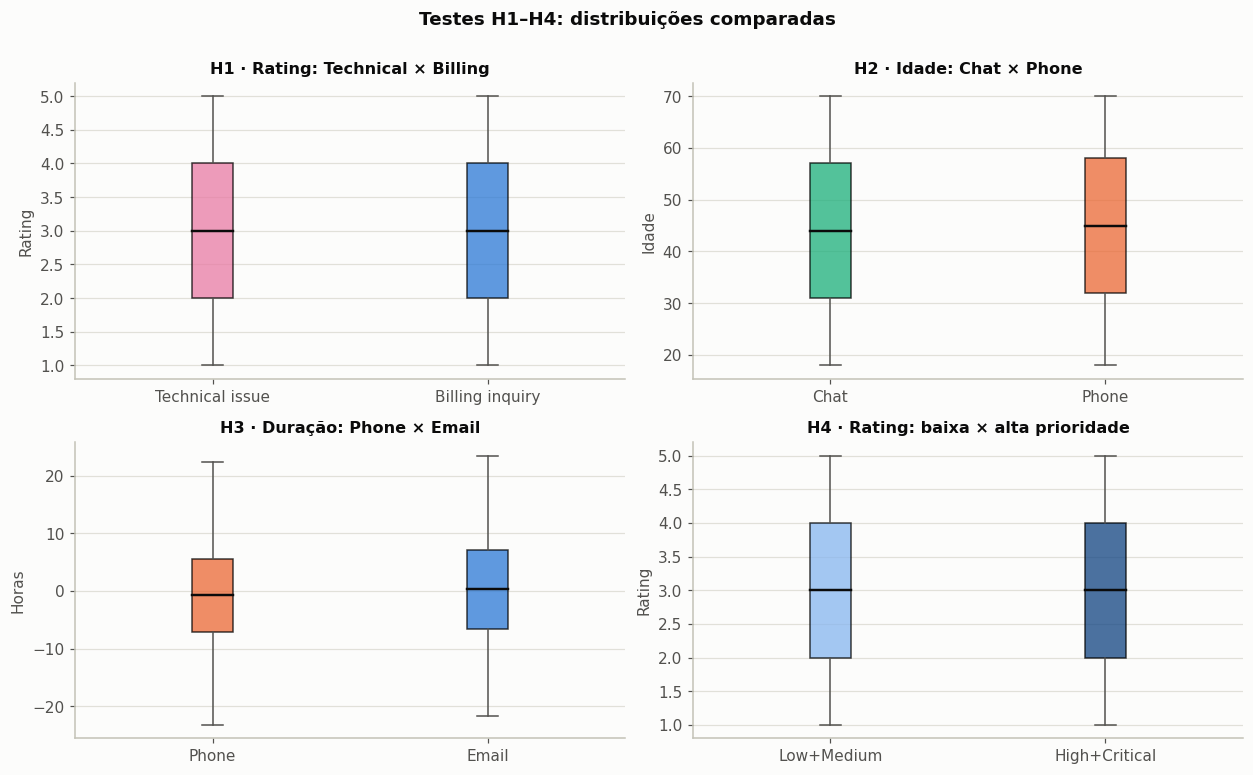

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.0))
pairs = [
    ("H1 · Rating: Technical × Billing",
     [closed.loc[closed["Ticket Type"] == "Technical issue", "Customer Satisfaction Rating"],
      closed.loc[closed["Ticket Type"] == "Billing inquiry", "Customer Satisfaction Rating"]],
     ["Technical issue", "Billing inquiry"],
     [TYPE_COLORS["Technical issue"], TYPE_COLORS["Billing inquiry"]]),
    ("H2 · Idade: Chat × Phone",
     [clean.loc[clean["Ticket Channel"] == "Chat", "Customer Age"],
      clean.loc[clean["Ticket Channel"] == "Phone", "Customer Age"]],
     ["Chat", "Phone"],
     [CHANNEL_COLORS["Chat"], CHANNEL_COLORS["Phone"]]),
    ("H3 · Duração: Phone × Email",
     [closed.loc[closed["Ticket Channel"] == "Phone", "Resolution_Duration_Hours"],
      closed.loc[closed["Ticket Channel"] == "Email", "Resolution_Duration_Hours"]],
     ["Phone", "Email"],
     [CHANNEL_COLORS["Phone"], CHANNEL_COLORS["Email"]]),
    ("H4 · Rating: baixa × alta prioridade",
     [closed.loc[closed["Ticket Priority"].isin(["Low", "Medium"]), "Customer Satisfaction Rating"],
      closed.loc[closed["Ticket Priority"].isin(["High", "Critical"]), "Customer Satisfaction Rating"]],
     ["Low+Medium", "High+Critical"],
     ["#86b6ef", "#104281"]),
]
for ax, (title, data, cats, colors) in zip(axes.flat, pairs):
    style_ax(ax)
    bp = ax.boxplot(
        data,
        labels=cats,
        patch_artist=True,
        medianprops=dict(color=INK, linewidth=1.6),
        whiskerprops=dict(color=INK2),
        capprops=dict(color=INK2),
        boxprops=dict(linewidth=1.0),
        flierprops=dict(marker="o", markersize=3, markeredgecolor=INK2, markerfacecolor="none"),
        zorder=3,
    )
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_title(title, fontsize=10.5)
    ax.set_xlabel("")
    ax.set_ylabel("Rating" if "Rating" in title else ("Idade" if "Idade" in title else "Horas"))
fig.suptitle("Testes H1–H4: distribuições comparadas", fontweight="bold", color=INK, y=1.0)
plt.tight_layout()
plt.show()

### Resultados e interpretação

| Teste | Estatística | p | Efeito | Conclusão (α = 0,05) |
|---|---|---|---|---|
| H1 · Rating técnico × cobrança | U = 153.436 | 0,208 | r_b = +0,03 | Não rejeita H0 — satisfação equivalente |
| H2 · Idade Chat × Phone | U = 2.194.766 | 0,351 | r_b = +0,01 | Não rejeita H0 — sem diferença etária |
| H3 · Duração Phone × Email | U = 239.572 | 0,230 | r_b = +0,04 | Não rejeita H0 — canais equivalentes |
| H4 · Rating prioridade alta × baixa | U = 940.665 | 0,418 | r_b = +0,02 | Não rejeita H0 — prioridade não altera a experiência |
| H5 · Hora uniforme | χ²(23) = 38,0 | **0,026** | — | **Rejeita H0** — leve concentração às 19h (+24% sobre o esperado) |
| H6 · Subject ⊥ Type | χ²(60) = 39,6 | 0,981 | V = 0,034 | Não rejeita H0 — **independência das duas camadas de intenção** |

**Interpretação geral.** Em um dataset real de atendimento, esperaríamos associações claras
(ex.: prioridade alta → resolução mais rápida; problema técnico → pior satisfação). Nenhuma
aparece: os quatro testes de comparação de grupos têm efeitos desprezíveis (|r_b| ≤ 0,04), e as
duas únicas estruturas detectadas são artefatos — a concentração vespertina da hora (H5) e a
independência total entre assunto e intenção (H6). Isso **confirma formalmente** a natureza
sintética do dataset (Seção 3) e muda a estratégia de modelagem:

1. **`Ticket Subject` não pode ser usado como preditor de `Ticket Type`** (H6): as camadas de
   rótulo são independentes. O modelo deve prever a intenção a partir da descrição e tratar o
   assunto como alvo auxiliar, não como feature.
2. **Prioridade, canal, idade e produto não carregam sinal** (H1–H4, V de Cramér ≤ 0,03): o
   agente deve se apoiar no conteúdo textual, não em metadados.
3. **O único desvio significativo (H5)** é uma oscilação de ±24% na hora do atendimento dentro
   de uma janela sintética de 2,5 dias — sem valor operacional.

## 10. Documentação do EDA e conclusões (etapa 1.8)

### O que o EDA estabeleceu

| Etapa | Achado central | Decisão tomada |
|---|---|---|
| 1.1 Compreensão | Dataset sintético de 8.469 tickets de suporte; alvo de intenção (`Ticket Type`) em 5 classes | Adequado para o bloco; licença CC0 |
| 1.2 Inspeção | 17 colunas; só 2 numéricas puras; texto em `Subject`/`Description` | — |
| 1.3 Qualidade | Nulos **estruturais** (resolução/satisfação só existem em tickets `Closed`); 0 duplicatas; IDs íntegros; placeholder em 100% das descrições | Manter nulos; corrigir placeholder |
| 1.4 Limpeza | Tipagem temporal; placeholder → produto real; 4 variáveis derivadas de tempo/texto | Sem imputação; sem remoção de registros |
| 1.5 Univariada | Intenções e assuntos equilibrados; ~50% de prioridade High/Critical com só 33% fechados; ~75% de contatos textuais | — |
| 1.6 Multivariada | **Todas as associações ≈ 0** (V de Cramér ≤ 0,034; correlações ≈ 0) | Features de contexto não têm sinal discriminativo |
| 1.7 Outliers | 49% das durações de resolução negativas; correlação espúria duração×hora (−0,55); 512 descrições curtas | Manter tudo; não derivar SLA; documentar artefatos |
| 9. Testes formais | H1–H4 não significantes (\|r_b\| ≤ 0,04); H5 significante (hora, p = 0,026); H6: Subject ⊥ Type (p = 0,98) | Ver conclusões abaixo |

### Conclusões

1. **O dataset é sintético e estatisticamente "plano".** A geração uniforme e independente das
   variáveis — evidenciada agora por testes formais — limita o sinal disponível para o modelo
   e é, em si, o achado mais importante do EDA: o desempenho preditivo virá do texto e dos
   rótulos, não das features estruturadas.
2. **As duas camadas de intenção são independentes (H6).** Estratégia: prever `Ticket Type` a
   partir da descrição; não usar `Ticket Subject` como feature do alvo.
3. **Metadados não refletem urgência nem qualidade.** Prioridade, canal e idade são
   intercambiáveis (H1–H4): o agente não deve usar a prioridade declarada para escalonar.
4. **O texto precisa de normalização de templates** (69% em template fixo; o vocabulário de
   template domina até o ranking TF-IDF) — caso contrário, o classificador aprende artefatos
   lexicais.
5. **Base entregue para a modelagem:** `data/customer_support_tickets_clean.csv` — tipos
   corretos, placeholder corrigido e variáveis derivadas (`Hour_of_First_Response`,
   `Purchase_to_Ticket_Months`, `Resolution_Duration_Hours`, `Desc_Len`).

### Limitações

- Janela temporal única de ~2,5 dias: nenhuma sazonalidade real; timestamps sem causalidade.
- Satisfação só existe para os 33% de tickets `Closed`: qualquer modelo de satisfação sofre
  viés de seleção.
- Demografia uniforme e anonimizada: sem representatividade real.
- Textos gerados por templates: vocabulário real limitado; risco de overfitting lexical.

## 11. Elabore um DFD básico da API com as entradas, saídas e trust boundaries identificados. Aplique a tríade CIA para cada componente: o que é confidencial, o que precisa de integridade, o que deve estar disponível.


### 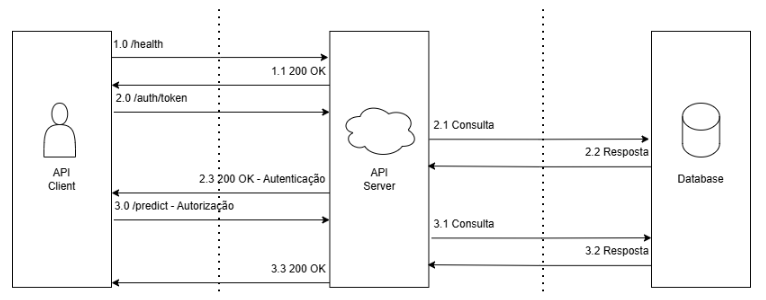

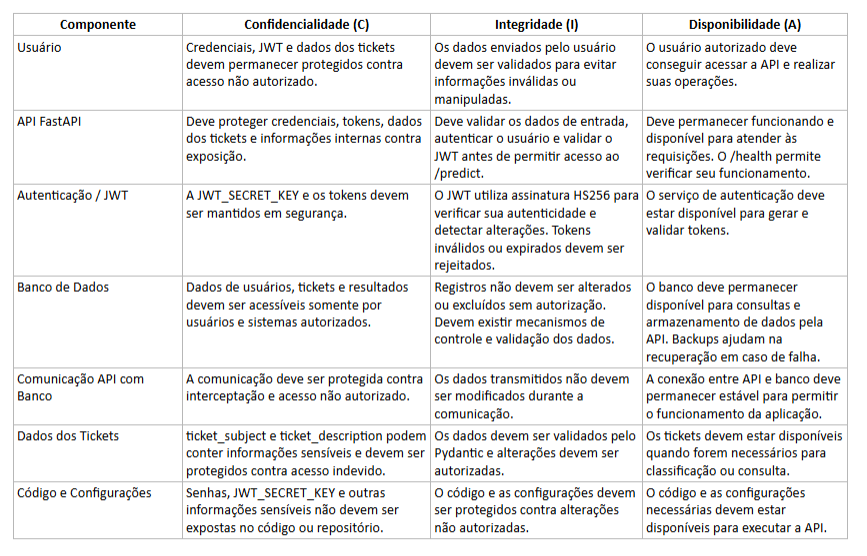